# 01 Comprensión de los datos

En esta fase se realiza una exploración inicial del dataset climático con el objetivo de comprender su estructura, identificar posibles problemas de calidad de datos y obtener una visión general de las variables disponibles para etapas posteriores del proyecto.

In [62]:
# Librerías necesarias para exploración y análisis inicial.
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos las rutas principales del proyecto.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
REPORTS_DIR = ROOT / "reports"

# Importamos funciones de visualización.
from src import visualization

# Aplicamos un estilo general para las gráficas.
visualization.set_style()


## Cargamos el dataset original

In [23]:
# Cargamos el dataset original.
raw_path = DATA_DIR / "raw" / "climate_change_dataset.csv"
df_raw = pd.read_csv(raw_path)


# Vista inicial del dataset

In [30]:
# Mostramos las primeras filas para inspeccionar la estructura general.
display(df_raw.head())
# Revisamos dimensiones del dataset.
print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]}")

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


Filas: 1,000
Columnas: 10


## Tipos de datos

In [31]:
# Inspeccionamos los tipos de dato de cada variable.
display(df_raw.dtypes.to_frame("tipo_dato"))

,tipo_dato
Year,int64
Country,str
Avg Temperature (°C),float64
CO2 Emissions (Tons/Capita),float64
Sea Level Rise (mm),float64
Rainfall (mm),int64
Population,int64
Renewable Energy (%),float64
Extreme Weather Events,int64
Forest Area (%),float64


## Diccionario de variables

| Variable                  | Tipo    | Descripción                 |
| ------------------------- | ------- | --------------------------- |
| year                      | int64   | Año del registro            |
| country                   | object  | País analizado              |
| avg_temperature_c         | float64 | Temperatura promedio anual  |
| co2_emissions_tons_capita | float64 | Emisiones de CO₂ per cápita |
| sea_level_rise_mm         | float64 | Aumento del nivel del mar   |
| rainfall_mm               | int64   | Precipitación anual         |
| population                | int64   | Población                   |
| renewable_energy_pct      | float64 | Energía renovable (%)       |
| extreme_weather_events    | int64   | Eventos climáticos extremos |
| forest_area_pct           | float64 | Cobertura forestal (%)      |


# Calidad de datos
## Valores faltantes

In [33]:
# Contamos valores faltantes por variable.
missing = df_raw.isna().sum().to_frame("missing_values")

missing["missing_pct"] = (
    missing["missing_values"] / len(df_raw) * 100
).round(2)

display(missing.sort_values("missing_values", ascending=False))

,missing_values,missing_pct
Year,0,0.0
Country,0,0.0
Avg Temperature (°C),0,0.0
CO2 Emissions (Tons/Capita),0,0.0
Sea Level Rise (mm),0,0.0
Rainfall (mm),0,0.0
Population,0,0.0
Renewable Energy (%),0,0.0
Extreme Weather Events,0,0.0
Forest Area (%),0,0.0


## Duplicados

In [36]:
# Identificamos registros duplicados exactos.
duplicated_rows = int(df_raw.duplicated().sum())

print("Duplicados exactos:", duplicated_rows)

Duplicados exactos: 0


## Cardinalidad

In [37]:
# Revisamos la cantidad de valores únicos por variable.
cardinality = pd.DataFrame({
    "tipo_dato": df_raw.dtypes.astype(str),
    "valores_unicos": df_raw.nunique(dropna=False)
})

display(cardinality)

,tipo_dato,valores_unicos
Year,int64,24
Country,str,15
Avg Temperature (°C),float64,292
CO2 Emissions (Tons/Capita),float64,194
Sea Level Rise (mm),float64,41
Rainfall (mm),int64,799
Population,int64,1000
Renewable Energy (%),float64,407
Extreme Weather Events,int64,15
Forest Area (%),float64,473


## Estadísticas descriptivas

In [38]:
# Generamos estadísticas descriptivas de variables numéricas.
display(df_raw.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
Year,1000.0,2.011430e+03,7.150000e+00,2000.0,2.005000e+03,2.012000e+03,2.018000e+03,2.023000e+03
Avg Temperature (°C),1000.0,1.988000e+01,8.540000e+00,5.0,1.218000e+01,2.010000e+01,2.722000e+01,3.490000e+01
CO2 Emissions (Tons/Capita),1000.0,1.043000e+01,5.610000e+00,0.5,5.570000e+00,1.070000e+01,1.540000e+01,2.000000e+01
Sea Level Rise (mm),1000.0,3.010000e+00,1.150000e+00,1.0,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
Rainfall (mm),1000.0,1.738760e+03,7.089800e+02,501.0,1.098750e+03,1.726000e+03,2.362500e+03,2.999000e+03
Population,1000.0,7.053830e+08,4.093910e+08,3660891.0,3.436242e+08,7.131166e+08,1.073868e+09,1.397016e+09
Renewable Energy (%),1000.0,2.730000e+01,1.297000e+01,5.1,1.610000e+01,2.715000e+01,3.892000e+01,5.000000e+01
Extreme Weather Events,1000.0,7.290000e+00,4.420000e+00,0.0,3.000000e+00,8.000000e+00,1.100000e+01,1.400000e+01
Forest Area (%),1000.0,4.057000e+01,1.740000e+01,10.1,2.560000e+01,4.115000e+01,5.580000e+01,7.000000e+01


## Validación de rangos

In [40]:
# Validamos porcentajes fuera del rango esperado.
invalid_renewable = df_raw[
    (df_raw["Renewable Energy (%)"] < 0) |
    (df_raw["Renewable Energy (%)"] > 100)
]

invalid_forest = df_raw[
    (df_raw["Forest Area (%)"] < 0) |
    (df_raw["Forest Area (%)"] > 100)
]

print("Renewable energy fuera de rango:", len(invalid_renewable))
print("Forest area fuera de rango:", len(invalid_forest))

Renewable energy fuera de rango: 0
Forest area fuera de rango: 0


## Distribuciones iniciales

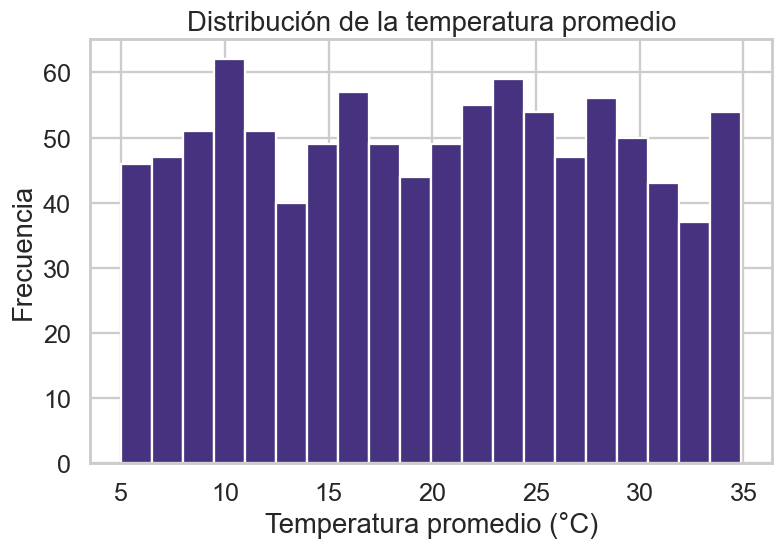

In [50]:
plt.figure(figsize=(8,5))

plt.hist(df_raw["Avg Temperature (°C)"], bins=20)

plt.title("Distribución de la temperatura promedio")
plt.xlabel("Temperatura promedio (°C)")
plt.ylabel("Frecuencia")

plt.show()

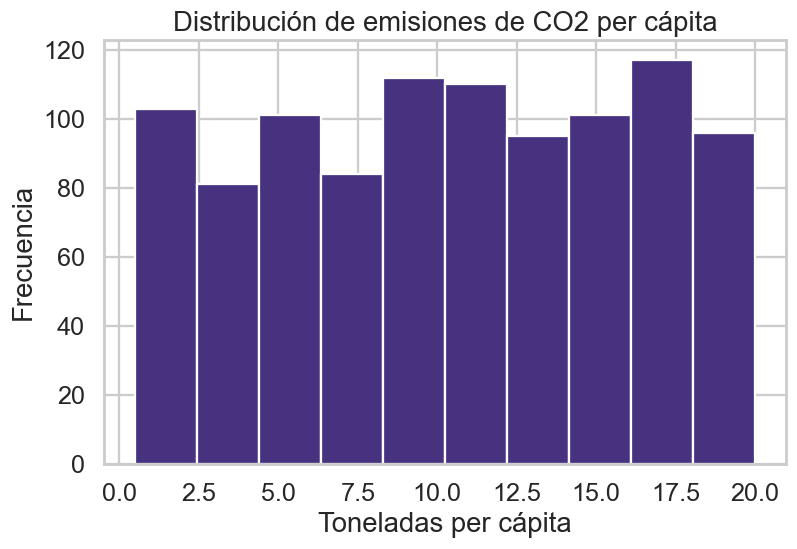

In [53]:
df_raw["CO2 Emissions (Tons/Capita)"].hist(figsize=(8,5))

plt.title("Distribución de emisiones de CO2 per cápita")
plt.xlabel("Toneladas per cápita")
plt.ylabel("Frecuencia")

plt.show()

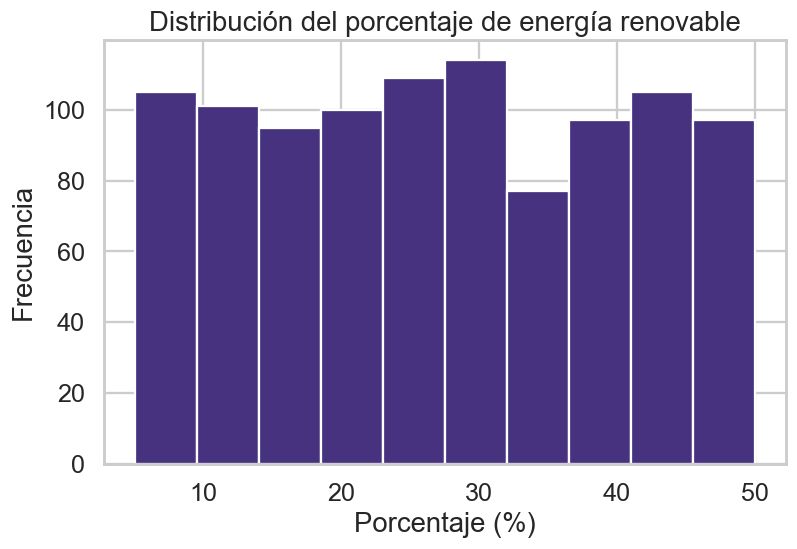

In [54]:
df_raw["Renewable Energy (%)"].hist(figsize=(8,5))

plt.title("Distribución del porcentaje de energía renovable")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Frecuencia")

plt.show()

## Correlaciones iniciales

In [58]:
corr = df_raw.select_dtypes(include=np.number).corr()
display(corr.round(2))


,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
Year,1.00,0.02,0.04,0.04,-0.01,0.07,0.02,-0.02,-0.04
Avg Temperature (°C),0.02,1.00,0.01,0.06,-0.00,0.00,-0.07,0.03,-0.02
CO2 Emissions (Tons/Capita),0.04,0.01,1.00,-0.04,0.01,0.01,-0.02,-0.00,0.03
Sea Level Rise (mm),0.04,0.06,-0.04,1.00,0.02,-0.00,0.00,0.03,-0.03
Rainfall (mm),-0.01,-0.00,0.01,0.02,1.00,0.01,-0.01,-0.01,0.02
Population,0.07,0.00,0.01,-0.00,0.01,1.00,0.00,0.01,-0.01
Renewable Energy (%),0.02,-0.07,-0.02,0.00,-0.01,0.00,1.00,0.00,-0.02
Extreme Weather Events,-0.02,0.03,-0.00,0.03,-0.01,0.01,0.00,1.00,-0.01
Forest Area (%),-0.04,-0.02,0.03,-0.03,0.02,-0.01,-0.02,-0.01,1.00


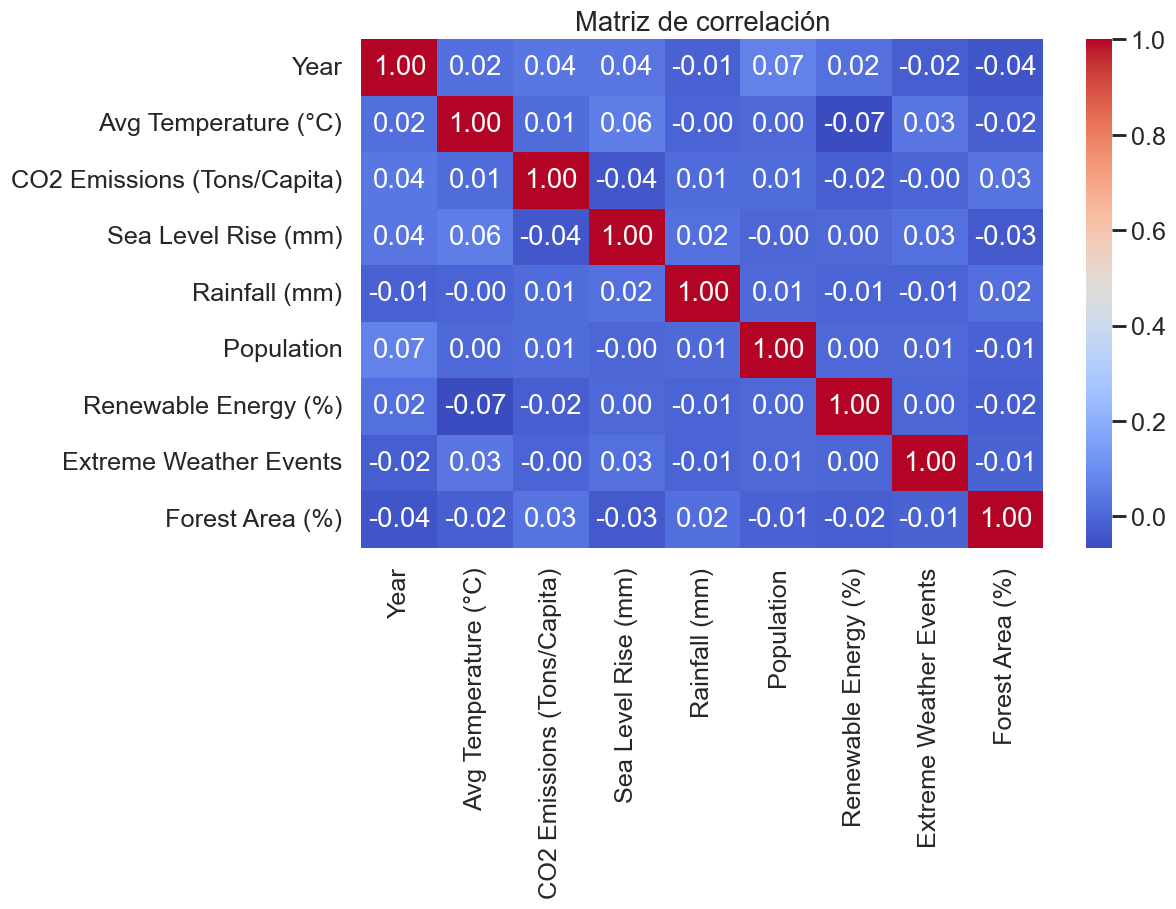

In [63]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

## Resultados
El dataset presenta una estructura consistente, sin valores faltantes ni duplicados exactos detectados en la exploración inicial. Las variables numéricas muestran escalas heterogéneas y algunas variables porcentuales requieren validación de rango durante la fase de limpieza. Asimismo, las correlaciones lineales observadas son débiles, por lo que será necesario complementar el análisis mediante técnicas exploratorias y modelos predictivos más robustos en etapas posteriores.